# Tutorial 21: Physics-informed DMD with Control (PiDMDc)

In this tutorial we introduce **PiDMDc**, a new method that combines the
manifold-constrained operator from **Physics-informed DMD** (PiDMD, Baddoo
et al. 2023) with the control input handling from **DMD with Control**
(DMDc, Proctor et al. 2016).

## Background

### DMD with Control (DMDc)

Standard DMD models an autonomous dynamical system
$\mathbf{x}_{k+1} = \mathbf{A}\mathbf{x}_k$.
DMDc extends this to *controlled* (actuated) systems:

$$
\mathbf{x}_{k+1} = \mathbf{A}\mathbf{x}_k + \mathbf{B}\mathbf{u}_k
$$

where $\mathbf{u}_k \in \mathbb{R}^m$ is the control input and
$\mathbf{B} \in \mathbb{R}^{n \times m}$ maps control inputs to state
changes. DMDc recovers both $\mathbf{A}$ and $\mathbf{B}$ from data.

### Physics-informed DMD (PiDMD)

PiDMD constrains the DMD operator $\mathbf{A}$ to lie on a known
**matrix manifold** $\mathcal{M}$. Instead of solving

$$
\mathbf{A}_{\text{DMD}} = \underset{\mathbf{A}}{\operatorname{argmin}}\;
\|\mathbf{Y} - \mathbf{A}\mathbf{X}\|_F
$$

PiDMD solves the **manifold-constrained Procrustes problem**:

$$
\mathbf{A}_{\text{PiDMD}} = \underset{\mathbf{A} \in \mathcal{M}}
{\operatorname{argmin}}\;
\|\mathbf{Y} - \mathbf{A}\mathbf{X}\|_F
$$

Supported manifolds include: unitary, symmetric, skew-symmetric,
diagonal (banded), Toeplitz, Hankel, circulant, block circulant,
upper/lower triangular, and their combinations (19 total).

### PiDMDc: Combining Both

PiDMDc solves the controlled system where $\mathbf{A}$ is
manifold-constrained:

$$
\mathbf{x}_{k+1} = \mathbf{A}\mathbf{x}_k + \mathbf{B}\mathbf{u}_k
\qquad \text{subject to} \quad \mathbf{A} \in \mathcal{M}
$$

Only $\mathbf{A}$ is constrained; $\mathbf{B}$ remains unconstrained.
This matches the physics: the manifold encodes the structure of the
**autonomous dynamics** (e.g. energy conservation $\Rightarrow$ unitary),
while $\mathbf{B}$ is the actuation map which typically does not share
the same symmetry.

**Two modes of operation:**

| Mode | Description |
|------|-------------|
| **B known** | Subtract $\mathbf{B}\mathbf{u}_k$ from $\mathbf{Y}$, then apply PiDMD's Procrustes solver |
| **B unknown** | Augmented SVD on $\boldsymbol{\Omega} = [\mathbf{X}; \mathbf{U}]$ to separate state/control dynamics, learn $\mathbf{B}$, then apply manifold Procrustes |

## Imports

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment

from pydmd import DMDc
from pydmd.pidmdc import PiDMDc

warnings.filterwarnings("ignore")

## Part 1: PiDMDc with Known B

We consider a controlled system where $\mathbf{A}$ is a **unitary**
(rotation) matrix and $\mathbf{B}$ is known. The unitary constraint
encodes energy conservation — a common physical prior for oscillatory
systems.

We define $\mathbf{A}$ as a block-diagonal rotation:

$$
\mathbf{A} = \text{diag}\!\left(
\begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta
\end{pmatrix},\;
\ldots
\right), \quad \theta = \pi/6
$$

and simulate $\mathbf{x}_{k+1} = \mathbf{A}\mathbf{x}_k +
\mathbf{B}\mathbf{u}_k$ for 200 time steps with small random control
inputs.

In [2]:
# Define a unitary rotation operator (block-diagonal rotations).
theta = np.pi / 6
A_block = np.array(
    [[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]]
)
n = 8  # state dimension
A_true = np.block(
    [
        [A_block if i == j else np.zeros((2, 2)) for j in range(n // 2)]
        for i in range(n // 2)
    ]
)

# Define the control input matrix.
rng = np.random.default_rng(seed=42)
m = 2  # control dimension
B_true = rng.standard_normal((n, m)) * 0.5

# Simulate the controlled system.
T = 200
x0 = rng.standard_normal(n)
u = 0.05 * rng.standard_normal((m, T - 1))

snapshots = np.empty((n, T))
snapshots[:, 0] = x0
for k in range(T - 1):
    snapshots[:, k + 1] = A_true.dot(snapshots[:, k]) + B_true.dot(u[:, k])

print(f"Snapshots shape: {snapshots.shape}")
print(f"Control input shape: {u.shape}")

Snapshots shape: (8, 200)
Control input shape: (2, 199)


### Fitting PiDMDc with the unitary manifold

We fit a `PiDMDc` model with `manifold="unitary"` and provide the known
$\mathbf{B}$. The method subtracts the control contribution
$\mathbf{B}\mathbf{u}_k$ from the output snapshots, then applies the
unitary Procrustes solver to recover $\mathbf{A}$.

In [3]:
# Fit PiDMDc with known B and unitary manifold constraint.
pidmdc = PiDMDc("unitary", compute_A=True, svd_rank=-1)
pidmdc.fit(snapshots, u, B_true)

# Verify that A is unitary: A^H A should be the identity.
AHA = pidmdc.A.conj().T.dot(pidmdc.A)
print("A^H A (should be identity):")
print(np.round(np.real(AHA), 4))

A^H A (should be identity):
[[ 1. -0. -0. -0. -0.  0. -0. -0.]
 [-0.  1.  0. -0. -0. -0.  0.  0.]
 [-0.  0.  1.  0.  0.  0. -0.  0.]
 [-0. -0.  0.  1. -0. -0. -0. -0.]
 [-0. -0.  0. -0.  1. -0. -0. -0.]
 [ 0. -0.  0. -0. -0.  1.  0. -0.]
 [-0.  0. -0. -0. -0.  0.  1. -0.]
 [-0.  0.  0. -0. -0. -0. -0.  1.]]


Since $\mathbf{A}$ is constrained to the unitary manifold, its
eigenvalues must lie **exactly on the unit circle** ($|\lambda_i| = 1$).
This is the key advantage over unconstrained DMDc, which may produce
eigenvalues that drift off the unit circle due to noise or finite data.

In [4]:
# Verify eigenvalues lie on the unit circle.
eig_mags = np.abs(pidmdc.eigs)
print(f"Eigenvalue magnitudes: {np.round(eig_mags, 6)}")
print(f"All on unit circle: {np.allclose(eig_mags, 1.0)}")

Eigenvalue magnitudes: [1. 1. 1. 1. 1. 1. 1. 1.]
All on unit circle: True


### Reconstruction

We reconstruct the state trajectory using the fitted model via the
iterative formula:

$$
\hat{\mathbf{x}}_{k+1} = \boldsymbol{\Phi}\,
\text{diag}(\boldsymbol{\lambda})\,
\boldsymbol{\Phi}^{\dagger}\,\hat{\mathbf{x}}_k
+ \mathbf{B}\mathbf{u}_k
$$

where $\boldsymbol{\Phi}$ are the DMD modes and $\boldsymbol{\lambda}$
are the eigenvalues.

Relative reconstruction error: 5.553765e-13


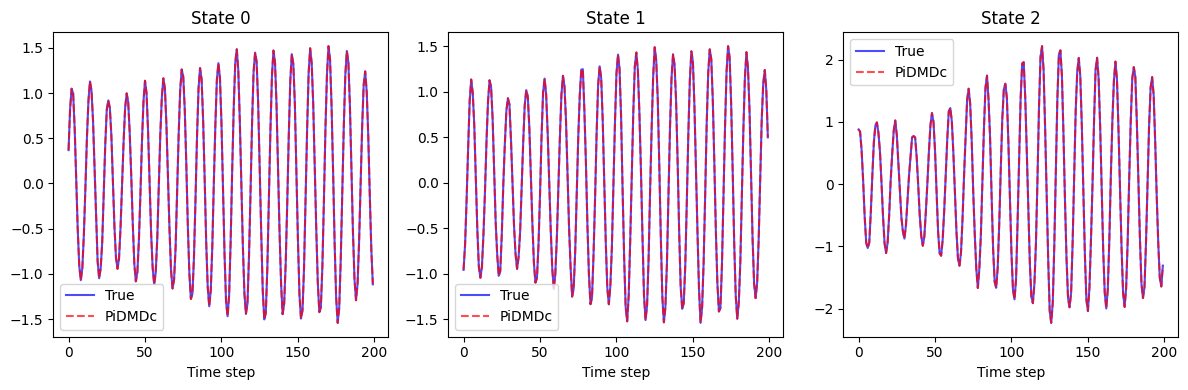

In [5]:
# Reconstruct and compare.
reconstructed = pidmdc.reconstructed_data()
err = np.linalg.norm(reconstructed - snapshots) / np.linalg.norm(snapshots)
print(f"Relative reconstruction error: {err:.6e}")

plt.figure(figsize=(12, 4))
for i in range(min(3, n)):
    plt.subplot(1, 3, i + 1)
    plt.plot(snapshots[i, :], "b-", alpha=0.7, label="True")
    plt.plot(reconstructed[i, :], "r--", alpha=0.7, label="PiDMDc")
    plt.title(f"State {i}")
    plt.xlabel("Time step")
    plt.legend()
plt.tight_layout()
plt.show()

## Part 2: PiDMDc with Unknown B

When $\mathbf{B}$ is not known, PiDMDc uses an **augmented SVD** to
jointly decompose the state and control dynamics. The augmented matrix
is:

$$
\boldsymbol{\Omega} = \begin{pmatrix} \mathbf{X} \\ \mathbf{U}
\end{pmatrix}
$$

An SVD of $\boldsymbol{\Omega}$ separates the state subspace from the
control subspace. $\mathbf{B}$ is recovered from the control subspace,
and the manifold-constrained Procrustes solver is applied to the
corrected state data.

In [6]:
pidmdc_unk = PiDMDc(
    "unitary", compute_A=True, svd_rank=-1, svd_rank_omega=-1, opt=True
)
pidmdc_unk.fit(snapshots, u)

print(f"Learned B shape: {pidmdc_unk.B.shape}")
print(f"Eigenvalue magnitudes: {np.round(np.abs(pidmdc_unk.eigs), 6)}")

reconstructed_unk = pidmdc_unk.reconstructed_data()
err_unk = np.linalg.norm(reconstructed_unk - snapshots) / np.linalg.norm(
    snapshots
)
print(f"Relative reconstruction error (B unknown): {err_unk:.6e}")

Learned B shape: (8, 2)
Eigenvalue magnitudes: [1. 1. 1. 1. 1. 1. 1. 1.]
Relative reconstruction error (B unknown): 5.357818e-14


## Part 3: Noise Robustness — PiDMDc vs DMDc

The key advantage of PiDMDc is that the manifold constraint acts as a
**physics-informed regularizer**. When the true system is known to be
unitary (energy-conserving), constraining $\mathbf{A}$ to the unitary
manifold reduces the degrees of freedom in the optimization and
prevents overfitting to noise.

**Important:** For both PiDMDc and DMDc, SVD rank truncation is critical
for noise robustness. Using `svd_rank=0` applies the optimal hard
threshold (Gavish & Donoho 2014), which automatically discards singular
values dominated by noise. Without truncation (`svd_rank=-1`), the
Procrustes solver fits noise in low-energy directions, degrading
eigenvalue recovery.

We compare **PiDMDc** (unitary, `svd_rank=0`) against **DMDc**
(`svd_rank=0`) by fitting both to noisy data at various noise levels.
Eigenvalues are matched using the **Hungarian algorithm** (optimal
assignment) to avoid spurious errors from permutation mismatches:

$$
\text{error} = \min_{\pi} \frac{\|\boldsymbol{\lambda}_{\text{computed}}
- \boldsymbol{\lambda}_{\text{true}}^{\pi}\|}
{\|\boldsymbol{\lambda}_{\text{true}}\|}
$$

In [7]:
def matched_eig_error(computed, true):
    """Eigenvalue error with optimal (Hungarian) matching."""
    cost = np.abs(computed[:, None] - true[None, :])
    row_ind, col_ind = linear_sum_assignment(cost)
    return np.linalg.norm(computed[row_ind] - true[col_ind]) / np.linalg.norm(
        true
    )


noise_levels = np.logspace(-6, -1, 12)
n_trials = 50

pidmdc_errors = np.zeros((len(noise_levels), n_trials))
dmdc_errors = np.zeros((len(noise_levels), n_trials))

# True eigenvalues of A.
true_eigs = np.linalg.eigvals(A_true)

for i, noise in enumerate(noise_levels):
    for j in range(n_trials):
        rng_trial = np.random.default_rng(seed=1000 * i + j)
        noisy_snapshots = snapshots + noise * rng_trial.standard_normal(
            snapshots.shape
        )

        # PiDMDc with unitary constraint and optimal SVD truncation
        try:
            pidmdc_trial = PiDMDc("unitary", svd_rank=0)
            pidmdc_trial.fit(noisy_snapshots, u, B_true)
            pidmdc_errors[i, j] = matched_eig_error(
                pidmdc_trial.eigs, true_eigs
            )
        except Exception:
            pidmdc_errors[i, j] = np.nan

        # Standard DMDc with optimal SVD truncation
        try:
            dmdc_trial = DMDc(svd_rank=0)
            dmdc_trial.fit(noisy_snapshots, u, B_true)
            dmdc_errors[i, j] = matched_eig_error(
                dmdc_trial.eigs, true_eigs
            )
        except Exception:
            dmdc_errors[i, j] = np.nan

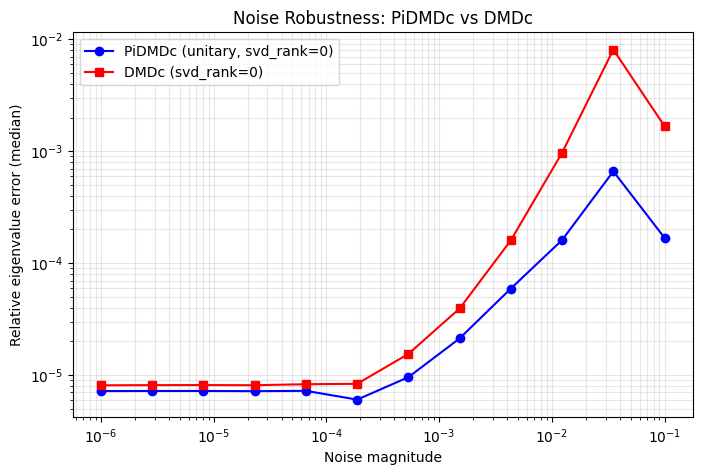

In [8]:
plt.figure(figsize=(8, 5))
plt.loglog(
    noise_levels,
    np.nanmedian(pidmdc_errors, axis=1),
    "bo-",
    label="PiDMDc (unitary, svd_rank=0)",
)
plt.loglog(
    noise_levels,
    np.nanmedian(dmdc_errors, axis=1),
    "rs-",
    label="DMDc (svd_rank=0)",
)
plt.xlabel("Noise magnitude")
plt.ylabel("Relative eigenvalue error (median)")
plt.title("Noise Robustness: PiDMDc vs DMDc")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

## Part 4: Different Manifolds

PiDMDc supports **all 19 manifolds** from PiDMD. The choice of manifold
encodes different physical priors about the autonomous dynamics:

| Manifold | Physical Interpretation |
|----------|----------------------|
| `"unitary"` | Energy-conserving (e.g. oscillatory) |
| `"symmetric"` | Self-adjoint with real eigenvalues |
| `"skewsymmetric"` | Self-adjoint with purely imaginary eigenvalues |
| `"diagonal"` | Fully decoupled / local dynamics |
| `"circulant"` | Shift-equivariant (periodic boundary) |
| `"toeplitz"` | Shift-equivariant (Dirichlet boundary) |

Below we visualize the recovered operator $\mathbf{A}$ under four
different manifold constraints applied to the same data.

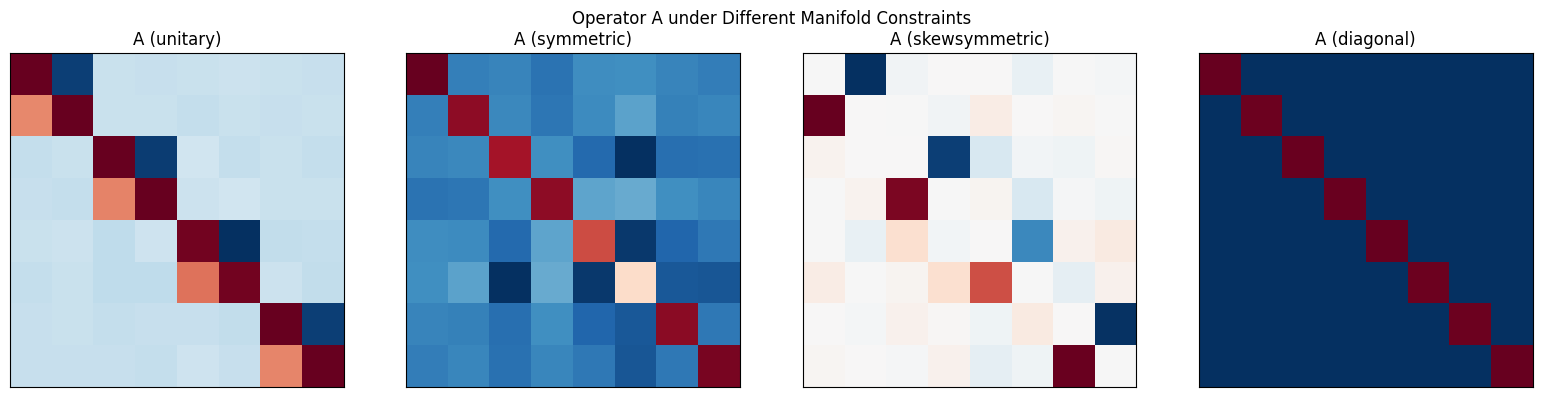

In [9]:
manifolds_to_test = ["unitary", "symmetric", "skewsymmetric", "diagonal"]
manifold_opts = [None, None, None, 1]

fig, axes = plt.subplots(1, len(manifolds_to_test), figsize=(16, 4))

for ax, manifold, mopt in zip(axes, manifolds_to_test, manifold_opts):
    pidmdc_m = PiDMDc(manifold, manifold_opt=mopt, compute_A=True)
    pidmdc_m.fit(snapshots, u, B_true)
    ax.imshow(np.real(pidmdc_m.A), cmap="RdBu_r", aspect="equal")
    ax.set_title(f"A ({manifold})")
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Operator A under Different Manifold Constraints")
plt.tight_layout()
plt.show()

## Part 5: Prediction with New Controls

A key use case for DMDc/PiDMDc is **predicting system behavior under
new control inputs**. After fitting the model on observed data, we can
simulate the system response to an arbitrary control signal by iterating:

$$
\hat{\mathbf{x}}_{k+1} = \boldsymbol{\Phi}\,
\text{diag}(\boldsymbol{\lambda})\,
\boldsymbol{\Phi}^{\dagger}\,\hat{\mathbf{x}}_k
+ \mathbf{B}\mathbf{u}_k^{\text{new}}
$$

Here we fit on data with random controls, then predict the response to
a **step input** on the first control channel.

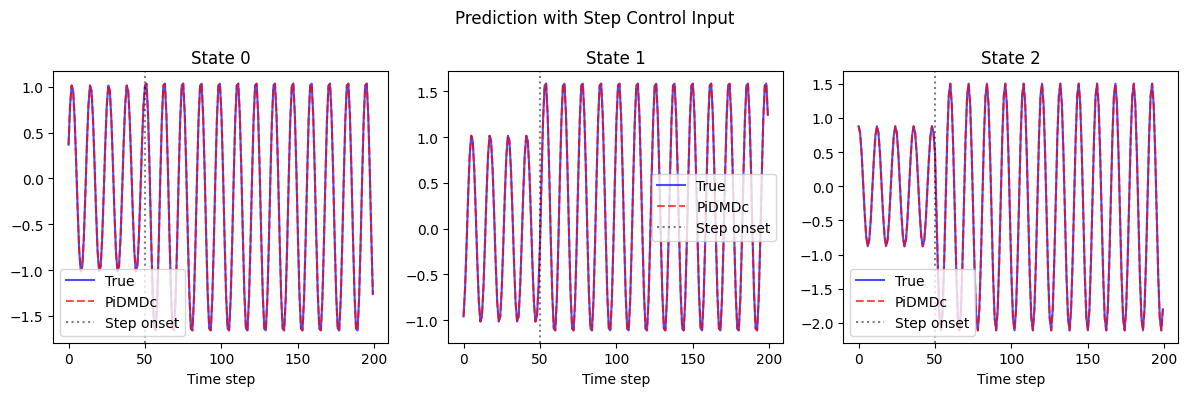

Tutorial complete!


In [10]:
# Fit PiDMDc.
pidmdc_pred = PiDMDc("unitary", svd_rank=-1)
pidmdc_pred.fit(snapshots, u, B_true)

# Generate new control: step input.
u_step = np.zeros_like(u)
u_step[0, 50:] = 0.5  # step on first control channel

# Predict with new controls.
pred_step = pidmdc_pred.reconstructed_data(u_step)

# Also generate the "true" response to the step input.
true_step = np.empty_like(snapshots)
true_step[:, 0] = snapshots[:, 0]
for k in range(T - 1):
    true_step[:, k + 1] = A_true.dot(true_step[:, k]) + B_true.dot(
        u_step[:, k]
    )

plt.figure(figsize=(12, 4))
for i in range(min(3, n)):
    plt.subplot(1, 3, i + 1)
    plt.plot(true_step[i, :], "b-", alpha=0.7, label="True")
    plt.plot(pred_step[i, :], "r--", alpha=0.7, label="PiDMDc")
    plt.axvline(50, color="k", linestyle=":", alpha=0.5, label="Step onset")
    plt.title(f"State {i}")
    plt.xlabel("Time step")
    plt.legend()
plt.suptitle("Prediction with Step Control Input")
plt.tight_layout()
plt.show()

print("Tutorial complete!")

## References

1. Baddoo, P.J., Herrmann, B., McKeon, B.J., Kutz, J.N. and Brunton,
   S.L., 2023. *Physics-informed dynamic mode decomposition*.
   Proceedings of the Royal Society A, 479(2271), p.20220576.
   [DOI](https://doi.org/10.1098/rspa.2022.0576)

2. Proctor, J.L., Brunton, S.L. and Kutz, J.N., 2016. *Dynamic mode
   decomposition with control*. SIAM Journal on Applied Dynamical
   Systems, 15(1), pp.142-161.
   [DOI](https://doi.org/10.1137/15M1013857)